In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os
import glob
import pandas as pd

sys.path.append(os.path.abspath('..'))

from src.preprocessing.clean_data import DataCleaner
from src.preprocessing.feature_engineering import FeatureEngineer

input_folder = "../datasets/DataSets-LF/"
output_folder = "../datasets/final/"

archivos_excel = glob.glob(input_folder + "*.xlsx")

for ruta_archivo in archivos_excel:
    nombre_base = os.path.basename(ruta_archivo)
    nombre_sin_ext = os.path.splitext(nombre_base)[0]
    
    print(f"Procesando: {nombre_base}...")
    
    try:
        # Pipeline completo
        df = pd.read_excel(ruta_archivo, header=8)
        df_clean = DataCleaner(df).clean()
        df_final = FeatureEngineer(df_clean).generate_features()
        
        # Guardar en la carpeta final
        ruta_salida = os.path.join(output_folder, f"{nombre_sin_ext}_final.csv")
        df_final.to_csv(ruta_salida, index=False)
        
    except Exception as e:
        print(f" Error procesando {nombre_base}: {e}")

print("¡Pipeline masivo completado con éxito!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Procesando: AGUA OXIGENADA 10.xlsx...
Procesando: ALCOHOL 70%.xlsx...
Procesando: AMOXICILINA 500MG-MSPHARMA.xlsx...
Procesando: AMOXICILINA500MG-PHARMAGENERICOS.xlsx...
Procesando: AZITROMICINA 500MG-ACFARMA.xlsx...
Procesando: AZITROMICINA500MG-GENFAR.xlsx...
Procesando: CETIRIZINA10MG-ACFARMA.xlsx...
Procesando: CETIRIZINA10MG-FARMAGENER.xlsx...
Procesando: DICLOFENACO 100MG-GENFAR.xlsx...
Procesando: DICLOFENACO 50MG-GENFAR.xlsx...
Procesando: DIMENHIDRINATO 50MG-PORTUGAL.xlsx...
Procesando: ENALAPRIL 20MG-FARMAGENERICO .xlsx...
Procesando: ENALAPRIL 20MG-PORTRUGAL.xlsx...
Procesando: IBUPROFENO400mg-GENFAR.xlsx...
Procesando: IBUPROFENO800mg-GENFAR.xlsx...
Procesando: LOPERAMIDA 2MG.xlsx...
Procesando: LORATADINA 10MG-PERUFARMA.xlsx...
Procesando: LOSARTAN 50MG -GENFAR.xlsx...
Procesando: LOSARTÁN 100MG-GENFAR.xlsx...
Procesando: METFORMINA 850MG-GENFAR.xlsx...
Procesando: METFORMINA 850MG-LAB 

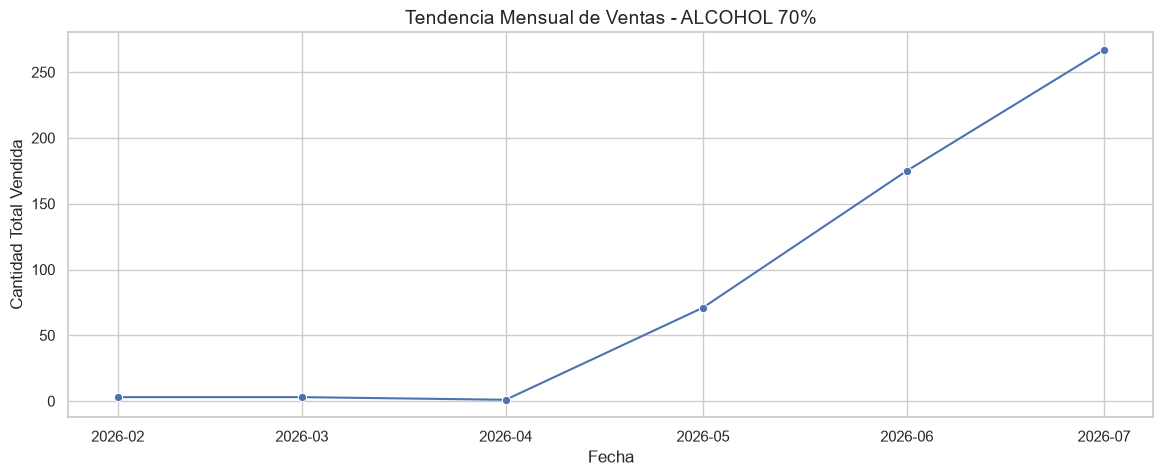

C:\Users\USER\AppData\Local\Temp\ipykernel_18324\216663593.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='estacion', y='cantidad', estimator=sum, errorbar=None, palette="viridis")


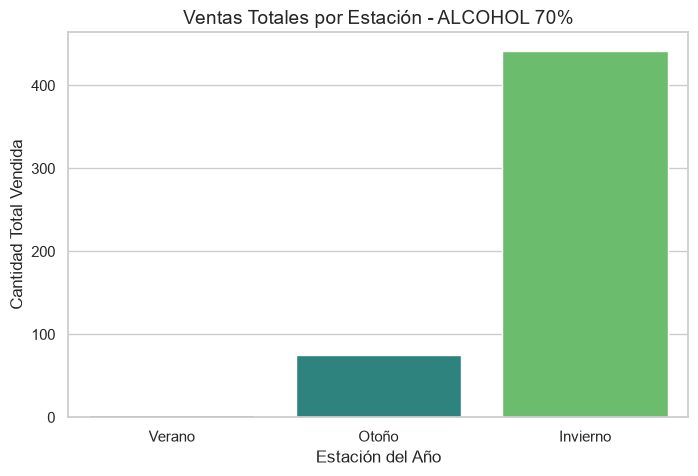

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_name = "ALCOHOL 70%" 
df_final = pd.read_csv(f"../datasets/final/{dataset_name}_final.csv")

df_final['fecdoc'] = pd.to_datetime(df_final['fecdoc'])

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))
ventas_mensuales = df_final.groupby(df_final['fecdoc'].dt.to_period('M'))['cantidad'].sum()
ventas_mensuales.index = ventas_mensuales.index.to_timestamp()

sns.lineplot(x=ventas_mensuales.index, y=ventas_mensuales.values, marker="o", color="b")
plt.title(f'Tendencia Mensual de Ventas - {dataset_name}', fontsize=14)
plt.ylabel('Cantidad Total Vendida')
plt.xlabel('Fecha')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df_final, x='estacion', y='cantidad', estimator=sum, errorbar=None, palette="viridis")
plt.title(f'Ventas Totales por Estación - {dataset_name}', fontsize=14)
plt.ylabel('Cantidad Total Vendida')
plt.xlabel('Estación del Año')
plt.show()

In [4]:
df_diario = df_final.groupby(df_final['fecdoc'].dt.date)['cantidad'].sum().reset_index()
df_diario['fecdoc'] = pd.to_datetime(df_diario['fecdoc'])

df_diario.set_index('fecdoc', inplace=True)

df_diario = df_diario.asfreq('D', fill_value=0)

train_size = int(len(df_diario) * 0.8) # 80% para entrenar

train_data = df_diario.iloc[:train_size]
test_data = df_diario.iloc[train_size:]

print(f"Total de días analizados: {len(df_diario)}")
print(f"Datos de Entrenamiento (Train): {len(train_data)} días")
print(f"Datos de Prueba (Test): {len(test_data)} días")

train_data.head()

Total de días analizados: 162
Datos de Entrenamiento (Train): 129 días
Datos de Prueba (Test): 33 días


,cantidad
fecdoc,
2026-02-20,1.0
2026-02-21,2.0
2026-02-22,0.0
2026-02-23,0.0
2026-02-24,0.0


In [ ]:
 "ALCOHOL 70%" 
df_final = pd.read_csv(f"../datasets/final/{dataset_name}_final.csv")
# Aseguramos que la fecha sea reconocida como tiempo y no como texto
df_final['fecdoc'] = pd.to_datetime(df_final['fecdoc'])

# 2. ASEGURAMOS LAS VARIABLES: Agrupamos por semana y dividimos Train/Test
df_semanal = df_final.set_index('fecdoc').resample('W')['cantidad'].sum()
train_size = int(len(df_semanal) * 0.8)
train = df_semanal.iloc[:train_size]
test = df_semanal.iloc[train_size:]

# 3. Definimos los rangos para p, d, q
rango_p = range(0, 4)
rango_d = range(0, 2)
rango_q = range(0, 4)

pdq_combinaciones = list(itertools.product(rango_p, rango_d, rango_q))
mejor_rmse = float("inf")
mejores_parametros = None
primer_error = None

print("Iniciando entrenamiento masivo de modelos ARIMA...")

# 4. Bucle de búsqueda
for parametros in pdq_combinaciones:
    try:
        # Entrenar modelo
        modelo = ARIMA(train, order=parametros)
        modelo_ajustado = modelo.fit()
        
        # Predecir
        predicciones = modelo_ajustado.forecast(steps=len(test))
        
        # Calcular error
        rmse_actual = np.sqrt(mean_squared_error(test, predicciones))
        
        # Guardar el mejor
        if rmse_actual < mejor_rmse:
            mejor_rmse = rmse_actual
            mejores_parametros = parametros
            print(f"Nuevo mejor modelo: ARIMA{parametros} - RMSE: {mejor_rmse:.2f}")
            
    except Exception as e:
        if primer_error is None:
            primer_error = str(e)
        continue

print("\n" + "="*40)
print(f"¡BÚSQUEDA TERMINADA!")
print(f"Mejores parámetros (p, d, q): {mejores_parametros}")
print(f"RMSE mínimo logrado: {mejor_rmse:.2f}")

if mejores_parametros is None:
    print(f"\n MOTIVO DEL FALLO: {primer_error}")
print("="*40)
          

Iniciando entrenamiento masivo de modelos ARIMA...
Nuevo mejor modelo: ARIMA(0, 0, 0) - RMSE: 45.36
Nuevo mejor modelo: ARIMA(0, 0, 1) - RMSE: 40.66
Nuevo mejor modelo: ARIMA(0, 0, 3) - RMSE: 34.54
Nuevo mejor modelo: ARIMA(0, 1, 0) - RMSE: 14.75
Nuevo mejor modelo: ARIMA(0, 1, 1) - RMSE: 13.51
Nuevo mejor modelo: ARIMA(0, 1, 3) - RMSE: 13.43
Nuevo mejor modelo: ARIMA(1, 1, 2) - RMSE: 12.50
Nuevo mejor modelo: ARIMA(2, 1, 2) - RMSE: 11.59
Nuevo mejor modelo: ARIMA(3, 1, 3) - RMSE: 9.35

¡BÚSQUEDA TERMINADA!
Mejores parámetros (p, d, q): (3, 1, 3)
RMSE mínimo logrado: 9.35


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
RESULTADOS FINALES ARIMA
MAE: 6.6
RMSE: 9.35
R2: -1.0178


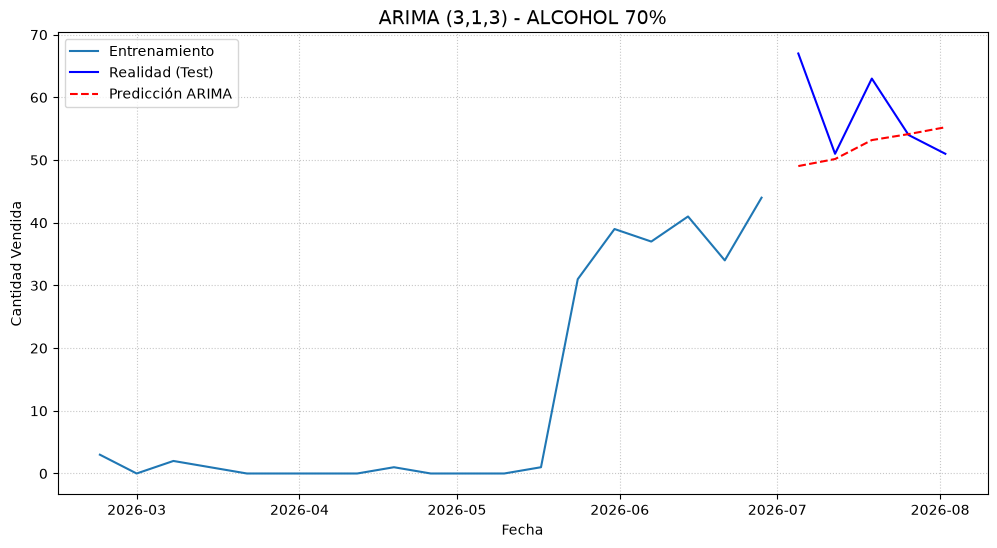

In [4]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# 1. Le decimos a Python que suba un nivel para poder ver la carpeta 'src'
sys.path.append(os.path.abspath('..'))

# 2. Ahora sí importamos tu modelo
from src.Modelos.arima_model import ArimaPredictor

# 3. Cargar datos limpios
df_final = pd.read_csv("../datasets/final/ALCOHOL 70%_final.csv")

# 4. Instanciar la clase y preparar datos
predictor = ArimaPredictor(df_final)
predictor.prepare_data()

# 5. Entrenar con nuestros mejores parámetros y obtener métricas
metricas = predictor.train_and_evaluate(order=(3, 1, 3))

print("RESULTADOS FINALES ARIMA")
for metrica, valor in metricas.items():
    print(f"{metrica}: {valor}")

# 6. Ver el gráfico comparativo
predictor.plot_results(title="ARIMA (3,1,3) - ALCOHOL 70%")

RESULTADOS FINALES: REGRESIÓN LINEAL
MAE: 13.79
RMSE: 14.26
R2: -3.6928


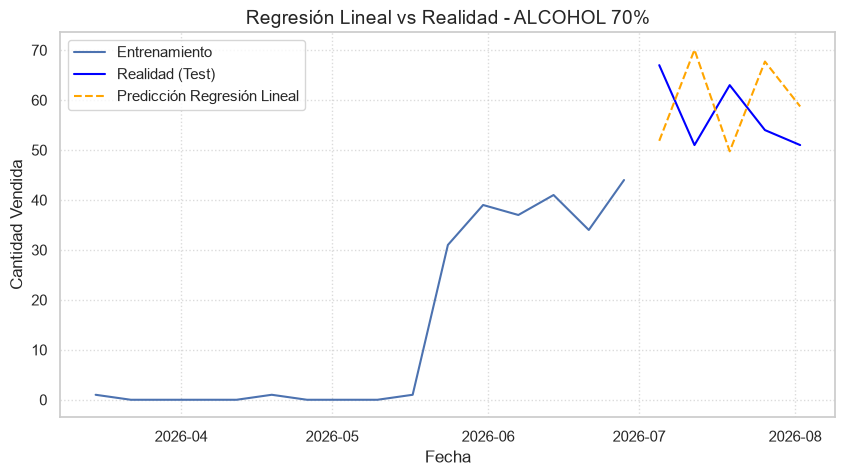

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Cargar y preparar los datos (Lags) exactamente igual que hicimos con XGBoost
dataset_name = "ALCOHOL 70%" 
df_final = pd.read_csv(f"../datasets/final/{dataset_name}_final.csv")
df_final['fecdoc'] = pd.to_datetime(df_final['fecdoc'])

df_semanal = df_final.set_index('fecdoc').resample('W')['cantidad'].sum().reset_index()

# Crear 3 semanas de retraso (lags) y la variable mes
lags = 3
for i in range(1, lags + 1):
    df_semanal[f'lag_{i}'] = df_semanal['cantidad'].shift(i)
df_semanal['mes'] = df_semanal['fecdoc'].dt.month
df_semanal.dropna(inplace=True)

# 2. División Train / Test (80% / 20%)
test_size = 0.2
train_len = int(len(df_semanal) * (1 - test_size))

X = df_semanal.drop(columns=['fecdoc', 'cantidad'])
y = df_semanal['cantidad']
fechas = df_semanal['fecdoc']

X_train, X_test = X.iloc[:train_len], X.iloc[train_len:]
y_train, y_test = y.iloc[:train_len], y.iloc[train_len:]
fechas_test = fechas.iloc[train_len:]
fechas_train = fechas.iloc[:train_len]

# 3. Entrenar el Modelo de Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# 4. Predecir
predicciones_lr = modelo_lr.predict(X_test)

# 5. Calcular las Métricas Finales
mae_lr = mean_absolute_error(y_test, predicciones_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, predicciones_lr))
r2_lr = r2_score(y_test, predicciones_lr)

print("RESULTADOS FINALES: REGRESIÓN LINEAL")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2: {r2_lr:.4f}")

# 6. Gráfico Comparativo
plt.figure(figsize=(10, 5))
plt.plot(fechas_train, y_train, label='Entrenamiento')
plt.plot(fechas_test, y_test, label='Realidad (Test)', color='blue')
plt.plot(fechas_test, predicciones_lr, label='Predicción Regresión Lineal', color='orange', linestyle='--')
plt.title('Regresión Lineal vs Realidad - ALCOHOL 70%', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Cantidad Vendida')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Cambiamos al dataset de agua oxigenada
dataset_name = "AGUA OXIGENADA 10_final.csv"  # Cambia esto si el archivo tiene otro nombre exacto

try:
    df_final = pd.read_csv(f"../datasets/final/AGUA OXIGENADA 10_final.csv")
except FileNotFoundError:
    # Si aún no está procesado en la carpeta final, lo procesamos al vuelo:
    df_raw = pd.read_excel(f"../datasets/DataSets-LF/{dataset_name}.xlsx", header=8)
    from src.preprocessing.clean_data import DataCleaner
    from src.preprocessing.feature_engineering import FeatureEngineer
    df_clean = DataCleaner(df_raw).clean()
    df_final = FeatureEngineer(df_clean).generate_features()
    df_final.to_csv(f"../datasets/final/{dataset_name}_final.csv", index=False)

# 2. Revisar el rango de fechas para confirmar si abarca 2025
df_final['fecdoc'] = pd.to_datetime(df_final['fecdoc'])
print(f"Rango de fechas en los datos: desde {df_final['fecdoc'].min().date()} hasta {df_final['fecdoc'].max().date()}")

# 3. Agrupación semanal rápida para probar ARIMA o Regresión Lineal
df_semanal = df_final.set_index('fecdoc').resample('W')['cantidad'].sum().reset_index()
print(f"Total de semanas registradas: {len(df_semanal)}")

# Mostrar un vistazo de las primeras filas
df_semanal.head()

Rango de fechas en los datos: desde 2025-01-02 hasta 2026-07-23
Total de semanas registradas: 82


,fecdoc,cantidad
0,2025-01-05,1.0
1,2025-01-12,2.0
2,2025-01-19,3.0
3,2025-01-26,2.0
4,2025-02-02,1.0


RESULTADOS CON HISTÓRICO (2025-2026) - AGUA OXIGENADA 10
MAE: 6.42
RMSE: 8.95
R2: 0.3356


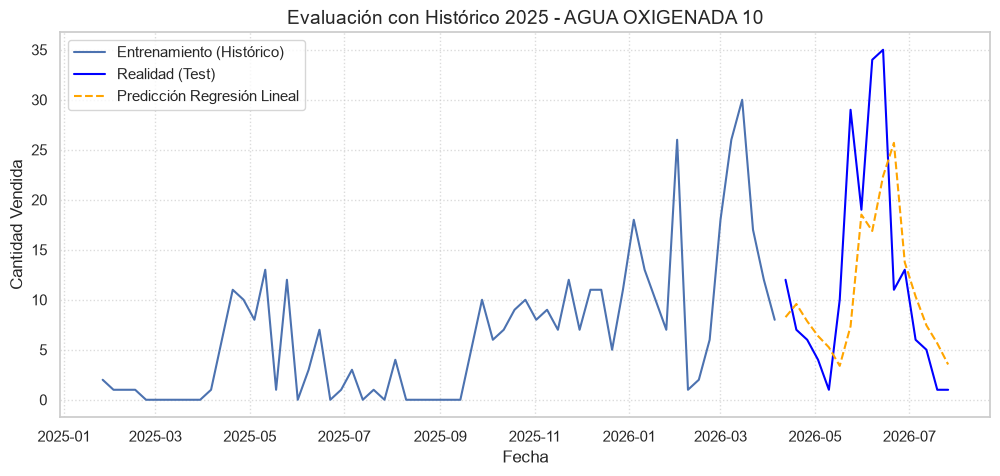

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Cargar el dataset de Agua Oxigenada
dataset_name = "AGUA OXIGENADA 10"  # Cambia por el nombre exacto de tu archivo procesado
df_final = pd.read_csv(f"../datasets/final/AGUA OXIGENADA 10_final.csv")
df_final['fecdoc'] = pd.to_datetime(df_final['fecdoc'])

# 2. Agrupar por semana y crear Lags (retrasos) y mes
df_semanal = df_final.set_index('fecdoc').resample('W')['cantidad'].sum().reset_index()

lags = 3
for i in range(1, lags + 1):
    df_semanal[f'lag_{i}'] = df_semanal['cantidad'].shift(i)
df_semanal['mes'] = df_semanal['fecdoc'].dt.month
df_semanal.dropna(inplace=True)

# 3. División Train / Test (Usaremos todo el 2025 para entrenar y parte del 2026 para probar)
# O el 80% tradicional que ya veníamos usando, pero ahora con 82 semanas son ~65 semanas de train
test_size = 0.2
train_len = int(len(df_semanal) * (1 - test_size))

X = df_semanal.drop(columns=['fecdoc', 'cantidad'])
y = df_semanal['cantidad']
fechas = df_semanal['fecdoc']

X_train, X_test = X.iloc[:train_len], X.iloc[train_len:]
y_train, y_test = y.iloc[:train_len], y.iloc[train_len:]
fechas_test = fechas.iloc[train_len:]
fechas_train = fechas.iloc[:train_len]

# 4. Entrenar Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
predicciones_lr = modelo_lr.predict(X_test)

# 5. Métricas
mae_lr = mean_absolute_error(y_test, predicciones_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, predicciones_lr))
r2_lr = r2_score(y_test, predicciones_lr)

print(f"RESULTADOS CON HISTÓRICO (2025-2026) - {dataset_name}")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2: {r2_lr:.4f}")

# 6. Gráfico
plt.figure(figsize=(12, 5))
plt.plot(fechas_train, y_train, label='Entrenamiento (Histórico)')
plt.plot(fechas_test, y_test, label='Realidad (Test)', color='blue')
plt.plot(fechas_test, predicciones_lr, label='Predicción Regresión Lineal', color='orange', linestyle='--')
plt.title(f'Evaluación con Histórico 2025 - {dataset_name}', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Cantidad Vendida')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

RESULTADOS DE XGBOOST CON HISTÓRICO
MAE: 8.7
RMSE: 12.27
R2: -0.2487


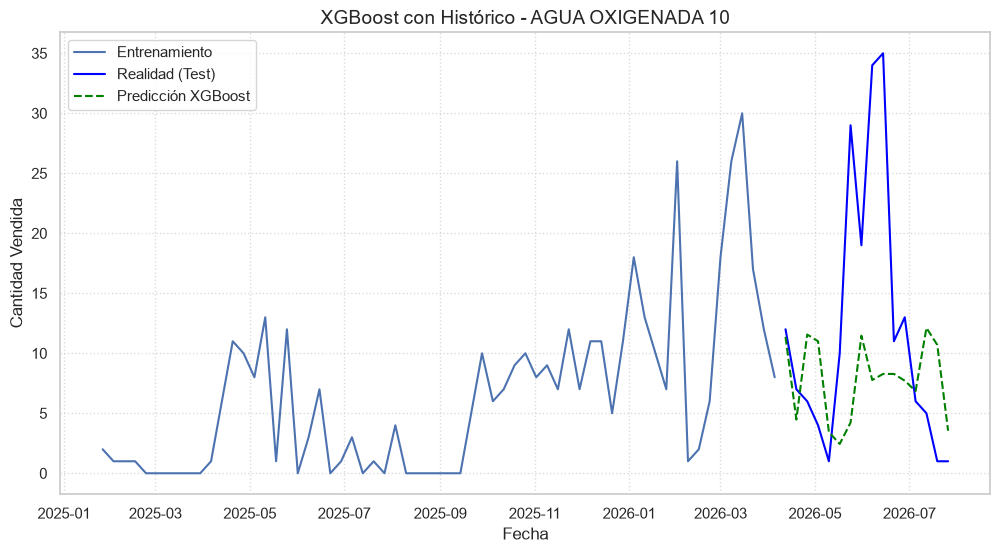

In [11]:
from src.Modelos.xgboost_model import XGBoostPredictor
import pandas as pd

# 1. Cargar el dataset de Agua Oxigenada
dataset_name = "AGUA OXIGENADA 10"
df_final = pd.read_csv(f"../datasets/final/AGUA OXIGENADA 10_final.csv")

# 2. Instanciar tu clase de XGBoost
xgb_predictor = XGBoostPredictor(df_final)

# 3. Preparar los datos (lags y meses con el histórico completo)
xgb_predictor.prepare_data()

# 4. Entrenar y evaluar
metricas_xgb = xgb_predictor.train_and_evaluate()

print("RESULTADOS DE XGBOOST CON HISTÓRICO")
for metrica, valor in metricas_xgb.items():
    print(f"{metrica}: {valor}")

# 5. Ver el gráfico
xgb_predictor.plot_results(title="XGBoost con Histórico - AGUA OXIGENADA 10")

In [13]:
from src.Modelos.linear_regression import RegresionLinealPredictor
from src.Modelos.random_forest import RandomForestPredictor

# --- 1. Regresión Lineal ---
lr = RegresionLinealPredictor()
res_lr = lr.train_and_evaluate(X_train, y_train, X_test, y_test)

# --- 2. Random Forest ---
rf = RandomForestPredictor()
res_rf = rf.train_and_evaluate(X_train, y_train, X_test, y_test)

# --- Mostrar tabla comparativa ---
print(f"RESULTADOS: {res_lr['Modelo']}")
print(f"MAE: {res_lr['MAE']}, RMSE: {res_lr['RMSE']}, R2: {res_lr['R2']}\n")

print(f"RESULTADOS: {res_rf['Modelo']}")
print(f"MAE: {res_rf['MAE']}, RMSE: {res_rf['RMSE']}, R2: {res_rf['R2']}")

RESULTADOS: Regresión Lineal
MAE: 6.42, RMSE: 8.95, R2: 0.3356

RESULTADOS: Random Forest
MAE: 7.97, RMSE: 11.35, R2: -0.068
